## 1. Problem Statement - Sinarmas Land

Masalah utama adalah membengkaknya defisit operasional Township Management akibat tingginya tunggakan IPL dari properti kosong serta ketidakteraturan pencatatan tagihan utilitas/air.

Pertanyaan analisis:

1. Township/cluster mana yang memiliki rasio tunggakan IPL tinggi dan bagaimana kontribusi unit **Vacant**?
2. Berapa estimasi nilai tagihan yang tertunda dari invoice yang menunggak lebih dari 6 bulan?
3. Seberapa tidak konsisten pencatatan **Payment Method**?
4. Berapa persentase unit dengan **contact number missing**?
5. Apakah terdapat invoice **Paid** dengan `payment_date` sebelum `handover_date`?
6. Berapa banyak invoice dengan outlier ekstrem pada `water_usage_m3`?

## 2. Goals

- **Revenue Recovery:** membangun aging analysis untuk memprioritaskan piutang.
- **Utility System Patching:** mendeteksi lonjakan pemakaian air yang tidak wajar.
- **Data Cleansing:** menstandarisasi payment method.
- **Anti-Fraud / Bug Fix:** menemukan pembayaran yang secara bisnis tidak mungkin terjadi sebelum handover.
- **Collection Readiness:** mengidentifikasi unit yang tidak memiliki nomor telepon.

## 3. Dataset Dictionary

### `sml_clusters.csv`
- `cluster_id`
- `township_name`
- `cluster_category`

### `sml_units.csv`
- `unit_id`
- `cluster_id`
- `owner_name`
- `contact_number`
- `is_vacant`
- `handover_date`

### `sml_ipl_billings.csv`
- `invoice_id`
- `unit_id`
- `billing_month`
- `water_usage_m3`
- `ipl_base_fee`
- `total_amount`
- `payment_status`
- `payment_method`
- `payment_date`

In [38]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


## 4. Data Loading

Letakkan ketiga CSV pada folder yang sama dengan notebook:

```text
sml_clusters.csv
sml_units.csv
sml_ipl_billings.csv
```

Jika file tidak ditemukan, synthetic dataset akan dibuat otomatis. Synthetic data sengaja mengandung beberapa data quality issue agar tahap wrangling dan visualisasi dapat diuji.

In [39]:
from pathlib import Path

DATA_DIR = Path(".")

cluster_path = DATA_DIR / "sml_clusters.csv"
unit_path = DATA_DIR / "sml_units.csv"
billing_path = DATA_DIR / "sml_ipl_billings.csv"

files_available = all(p.exists() for p in [cluster_path, unit_path, billing_path])

print("CSV tersedia:", files_available)

CSV tersedia: True


In [40]:
def create_synthetic_data(
    n_clusters=24,
    n_units=12000,
    n_bills=300000,
    seed=RANDOM_STATE
):
    rng = np.random.default_rng(seed)

    townships = ["BSD City", "Kota Wisata", "Grand Wisata", "NavaPark"]
    categories = ["Premium", "Middle", "Commercial"]

    clusters = pd.DataFrame({
        "cluster_id": [f"CL{i:03d}" for i in range(1, n_clusters + 1)],
        "township_name": rng.choice(townships, n_clusters),
        "cluster_category": rng.choice(categories, n_clusters, p=[0.25, 0.55, 0.20])
    })

    unit_cluster = rng.choice(clusters["cluster_id"], n_units)
    handover = pd.Timestamp("2018-01-01") + pd.to_timedelta(
        rng.integers(0, 9*365, n_units), unit="D"
    )

    units = pd.DataFrame({
        "unit_id": [f"UNIT{i:06d}" for i in range(1, n_units + 1)],
        "cluster_id": unit_cluster,
        "owner_name": [f"Owner {i:06d}" for i in range(1, n_units + 1)],
        "contact_number": [
            np.nan if rng.random() < 0.12 else f"08{rng.integers(100000000, 999999999)}"
            for _ in range(n_units)
        ],
        "is_vacant": rng.random(n_units) < 0.22,
        "handover_date": handover
    })

    # 25 monthly billing periods
    months = pd.date_range("2024-01-01", "2026-01-01", freq="MS")
    unit_idx = rng.integers(0, n_units, n_bills)
    billing_month = rng.choice(months, n_bills)

    water = np.clip(rng.gamma(shape=2.2, scale=3.0, size=n_bills), 0, None)
    
    # Inject extreme water-usage outliers
    outlier_idx = rng.choice(n_bills, int(n_bills * 0.003), replace=False)
    water[outlier_idx] *= rng.integers(30, 250, len(outlier_idx))

    vacant_flags = units.loc[unit_idx, "is_vacant"].to_numpy()
    statuses = rng.choice(["Paid", "Unpaid", "Overdue"], n_bills, p=[0.58, 0.22, 0.20])

    # Vacant units are intentionally more likely to be overdue/unpaid
    vacant_idx = np.where(vacant_flags)[0]
    vacant_status = rng.choice(["Paid", "Unpaid", "Overdue"], len(vacant_idx), p=[0.38, 0.27, 0.35])
    statuses[vacant_idx] = vacant_status

    # Deliberately inconsistent payment-method labels
    payment_methods = rng.choice(
        ["BCA VA", "BCA_VA", "BCA VA ", "Tokopedia", "tokopedia",
         "Cash", "cash", "CASH", "Bank Transfer", np.nan],
        n_bills,
        p=[.20,.05,.03,.18,.04,.08,.03,.02,.04,.33]
    )

    payment_date = np.array([pd.NaT] * n_bills, dtype="datetime64[ns]")
    paid_idx = np.where(statuses == "Paid")[0]
    payment_date[paid_idx] = billing_month[paid_idx] + pd.to_timedelta(
        rng.integers(0, 25, len(paid_idx)), unit="D"
    )

    # Inject impossible pre-handover payments into a subset of Paid invoices.
    eligible = paid_idx[units.loc[unit_idx[paid_idx], "handover_date"].to_numpy() > pd.Timestamp("2020-01-01")]
    bug_idx = rng.choice(eligible, min(900, len(eligible)), replace=False)
    payment_date[bug_idx] = units.loc[unit_idx[bug_idx], "handover_date"].to_numpy() - pd.to_timedelta(
        rng.integers(30, 700, len(bug_idx)), unit="D"
    )

    ipl_base_fee = rng.choice([75000, 100000, 125000, 150000, 200000], n_bills)
    water_fee = water * 8000
    late_fee = np.where(statuses == "Overdue", rng.choice([25000, 50000, 100000], n_bills), 0)
    total = ipl_base_fee + water_fee + late_fee

    billings = pd.DataFrame({
        "invoice_id": [f"INV{i:07d}" for i in range(1, n_bills + 1)],
        "unit_id": units.loc[unit_idx, "unit_id"].to_numpy(),
        "billing_month": pd.to_datetime(billing_month),
        "water_usage_m3": np.round(water, 2),
        "ipl_base_fee": ipl_base_fee.astype(float),
        "total_amount": np.round(total, 2),
        "payment_status": statuses,
        "payment_method": payment_methods,
        "payment_date": pd.to_datetime(payment_date)
    })

    return clusters, units, billings


if files_available:
    clusters = pd.read_csv(cluster_path)
    units = pd.read_csv(unit_path, dtype={"contact_number": "string"})
    billings = pd.read_csv(billing_path)
    print("Loaded real CSV files.")
else:
    clusters, units, billings = create_synthetic_data()
    print("CSV belum tersedia — synthetic dataset dibuat.")

print("clusters :", clusters.shape)
print("units    :", units.shape)
print("billings :", billings.shape)

Loaded real CSV files.
clusters : (100, 3)
units    : (25000, 6)
billings : (300000, 9)


In [41]:
display(clusters.head())
display(units.head())
display(billings.head())

,cluster_id,township_name,cluster_category
0,CLS-SML-001,BSD City,Middle Residential
1,CLS-SML-002,Grand Wisata,Middle Residential
2,CLS-SML-003,Kota Wisata,Middle Residential
3,CLS-SML-004,Grand Wisata,Middle Residential
4,CLS-SML-005,Grand Wisata,Commercial Ruko


,unit_id,cluster_id,owner_name,contact_number,is_vacant,handover_date
0,UNT-00001,CLS-SML-096,Pemilik Properti 0,08120452150,False,2021-10-24
1,UNT-00002,CLS-SML-075,Pemilik Properti 1,08117280852,True,2022-05-13
2,UNT-00003,CLS-SML-012,Pemilik Properti 2,08164339053,True,2022-06-19
3,UNT-00004,CLS-SML-035,Pemilik Properti 3,08180059262,False,2022-01-24
4,UNT-00005,CLS-SML-054,Pemilik Properti 4,08166340005,False,2020-12-30


,invoice_id,unit_id,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date
0,INV-IPL-00000001,UNT-17116,2023-08,48.0,850000,1210000.0,Paid,Cash,2023-08-17
1,INV-IPL-00000002,UNT-09718,2023-10,26.0,500000,695000.0,Unpaid,NaN,NaN
2,INV-IPL-00000003,UNT-20344,2024-06,1.0,350000,357500.0,Paid,Cash,2024-06-25
3,INV-IPL-00000004,UNT-23600,2024-02,17.0,850000,977500.0,Paid,KAS,2024-02-06
4,INV-IPL-00000005,UNT-12569,2023-05,1.0,850000,857500.0,Paid,toped,2023-05-08


## 5. Data Understanding

In [42]:
print("=== CLUSTERS ===")
clusters.info()
print("\n=== UNITS ===")
units.info()
print("\n=== BILLINGS ===")
billings.info()

=== CLUSTERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   cluster_id        100 non-null    object
 1   township_name     100 non-null    object
 2   cluster_category  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB

=== UNITS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   unit_id         25000 non-null  object
 1   cluster_id      25000 non-null  object
 2   owner_name      25000 non-null  object
 3   contact_number  20000 non-null  string
 4   is_vacant       25000 non-null  bool  
 5   handover_date   25000 non-null  object
dtypes: bool(1), object(4), string(1)
memory usage: 1001.1+ KB

=== BILLINGS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000

In [43]:
print("Numerical summary - Billings")
display(billings.describe(include="all").T)

print("Categorical summary - Units")
display(units.describe(include="all").T)

Numerical summary - Billings


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
invoice_id,300000,300000,INV-IPL-00000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_id,300000,25000,UNT-20096,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
billing_month,300000,69,2024-12,12477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
water_usage_m3,300000.0,NaN,NaN,NaN,71.49895,699.43306,-15.0,2.0,23.0,36.0,9999.0
ipl_base_fee,300000.0,NaN,NaN,NaN,799688.166667,442724.347395,350000.0,500000.0,500000.0,850000.0,1500000.0
total_amount,300000.0,NaN,NaN,NaN,1335930.291667,5265803.260213,237500.0,597500.0,850000.0,1500000.0,76492500.0
payment_status,300000,3,Paid,209722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,209722,9,toped,23449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_date,209722,1894,2023-12-08,369,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Categorical summary - Units


,count,unique,top,freq
unit_id,25000,25000,UNT-00001,1
cluster_id,25000,100,CLS-SML-099,304
owner_name,25000,25000,Pemilik Properti 0,1
contact_number,20000,19998,08122090946,2
is_vacant,25000,2,False,18822
handover_date,25000,1000,2021-05-13,43


In [44]:
def unique_summary(df):
    rows = []
    for col in df.columns:
        rows.append({
            "Column Name": col,
            "Number of Unique": df[col].nunique(dropna=True),
            "Missing Count": df[col].isna().sum(),
            "Missing %": round(df[col].isna().mean() * 100, 2),
            "Unique Sample": df[col].dropna().unique()[:10].tolist()
        })
    return pd.DataFrame(rows)

display(unique_summary(clusters))
display(unique_summary(units))
display(unique_summary(billings))

,Column Name,Number of Unique,Missing Count,Missing %,Unique Sample
0,cluster_id,100,0,0.0,"[CLS-SML-001, CLS-SML-002, CLS-SML-003, CLS-SML-004, CLS-SML-005, CLS-SML-006, CLS-SML-007, CLS-..."
1,township_name,5,0,0.0,"[BSD City, Grand Wisata, Kota Wisata, NavaPark, Deltamas]"
2,cluster_category,4,0,0.0,"[Middle Residential, Commercial Ruko, Premium Residential, Industrial/Commercial]"


,Column Name,Number of Unique,Missing Count,Missing %,Unique Sample
0,unit_id,25000,0,0.0,"[UNT-00001, UNT-00002, UNT-00003, UNT-00004, UNT-00005, UNT-00006, UNT-00007, UNT-00008, UNT-000..."
1,cluster_id,100,0,0.0,"[CLS-SML-096, CLS-SML-075, CLS-SML-012, CLS-SML-035, CLS-SML-054, CLS-SML-090, CLS-SML-089, CLS-..."
2,owner_name,25000,0,0.0,"[Pemilik Properti 0, Pemilik Properti 1, Pemilik Properti 2, Pemilik Properti 3, Pemilik Propert..."
3,contact_number,19998,5000,20.0,"[08120452150, 08117280852, 08164339053, 08180059262, 08166340005, 08159718364, 08186796837, 0811..."
4,is_vacant,2,0,0.0,"[False, True]"
5,handover_date,1000,0,0.0,"[2021-10-24, 2022-05-13, 2022-06-19, 2022-01-24, 2020-12-30, 2021-09-23, 2020-05-26, 2020-08-09,..."


,Column Name,Number of Unique,Missing Count,Missing %,Unique Sample
0,invoice_id,300000,0,0.00,"[INV-IPL-00000001, INV-IPL-00000002, INV-IPL-00000003, INV-IPL-00000004, INV-IPL-00000005, INV-I..."
1,unit_id,25000,0,0.00,"[UNT-17116, UNT-09718, UNT-20344, UNT-23600, UNT-12569, UNT-02418, UNT-04034, UNT-03893, UNT-064..."
2,billing_month,69,0,0.00,"[2023-08, 2023-10, 2024-06, 2024-02, 2023-05, 2024-12, 2024-05, 2023-03, 2023-12, 2023-04]"
3,water_usage_m3,45,0,0.00,"[48.0, 26.0, 1.0, 17.0, 21.0, 16.0, 0.0, 18.0, 22.0, 32.0]"
4,ipl_base_fee,4,0,0.00,"[850000, 500000, 350000, 1500000]"
5,total_amount,157,0,0.00,"[1210000.0, 695000.0, 357500.0, 977500.0, 857500.0, 657500.0, 620000.0, 350000.0, 1635000.0, 101..."
6,payment_status,3,0,0.00,"[Paid, Unpaid, Overdue]"
7,payment_method,9,90278,30.09,"[Cash, KAS, toped, BCA Virtual Account, Tokopedia, bca va, cc, VA BCA, Credit Card]"
8,payment_date,1894,90278,30.09,"[2023-08-17, 2024-06-25, 2024-02-06, 2023-05-08, 2024-05-18, 2023-04-10, 2023-09-16, 2024-11-15,..."


### Initial data-quality checkpoints

Hal yang perlu diperiksa sebelum analisis:

- Missing values pada `contact_number` dan `payment_method`.
- Konsistensi label `payment_method`.
- Duplikasi primary key.
- Tipe data tanggal.
- Referential integrity antara billing → unit → cluster.
- Nilai negatif / nol pada angka finansial dan pemakaian.
- Logical error: `Paid` tetapi `payment_date < handover_date`.

## 6. Data Cleaning & Wrangling

In [45]:
clusters_clean = clusters.copy()
units_clean = units.copy()
billings_clean = billings.copy()

for _df in [clusters_clean, units_clean, billings_clean]:
    _df.columns = (
        _df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

# Date conversion
units_clean["handover_date"] = pd.to_datetime(units_clean["handover_date"], errors="coerce")
billings_clean["billing_month"] = pd.to_datetime(billings_clean["billing_month"], errors="coerce")
billings_clean["payment_date"] = pd.to_datetime(billings_clean["payment_date"], errors="coerce")

# Numeric conversion
for col in ["water_usage_m3", "ipl_base_fee", "total_amount"]:
    billings_clean[col] = pd.to_numeric(billings_clean[col], errors="coerce")

print("Cleaning dasar selesai.")

Cleaning dasar selesai.


In [46]:
# 6.1 Duplicate checks
duplicate_report = pd.DataFrame({
    "dataset": ["clusters", "units", "billings"],
    "rows": [len(clusters_clean), len(units_clean), len(billings_clean)],
    "duplicate_rows": [
        clusters_clean.duplicated().sum(),
        units_clean.duplicated().sum(),
        billings_clean.duplicated().sum()
    ],
    "duplicate_primary_key": [
        clusters_clean["cluster_id"].duplicated().sum(),
        units_clean["unit_id"].duplicated().sum(),
        billings_clean["invoice_id"].duplicated().sum()
    ]
})

display(duplicate_report)

,dataset,rows,duplicate_rows,duplicate_primary_key
0,clusters,100,0,0
1,units,25000,0,0
2,billings,300000,0,0


In [47]:
# 6.2 Standardize Payment Method

payment_map = {
    "toped": "Tokopedia",
    "tokopedia": "Tokopedia",
    "kas": "Cash",
    "cash": "Cash",
    "cc": "Credit Card",
    "credit card": "Credit Card",
    "bca va": "BCA Virtual Account",
    "bca virtual account": "BCA Virtual Account",
    "va bca": "BCA Virtual Account"
}

# Keep original value for data-quality analysis
billings_clean["payment_method_raw"] = billings_clean["payment_method"]

# Standardize
billings_clean["payment_method"] = (
    billings_clean["payment_method"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(payment_map)
    .fillna("Unknown")
)

print("Payment method sebelum cleaning:")
display(
    billings_clean["payment_method_raw"]
    .value_counts(dropna=False)
)

print("Payment method setelah cleaning:")
display(
    billings_clean["payment_method"]
    .value_counts(dropna=False)
)

Payment method sebelum cleaning:


payment_method_raw
NaN                    90278
toped                  23449
KAS                    23438
Cash                   23370
cc                     23302
Credit Card            23267
bca va                 23242
Tokopedia              23238
BCA Virtual Account    23216
VA BCA                 23200
Name: count, dtype: int64

Payment method setelah cleaning:


payment_method
Unknown                90278
BCA Virtual Account    69658
Cash                   46808
Tokopedia              46687
Credit Card            46569
Name: count, dtype: int64

### 6.3 Water usage — dua jenis nilai tidak valid

Pada kolom `water_usage_m3` terdapat dua masalah yang secara konseptual berbeda dan **tidak boleh diperlakukan sama**:

1. **Nilai negatif (mis. `-15`)** — secara fisik mustahil: pemakaian air tidak bisa negatif. Ini adalah *hard invalid*.
2. **Nilai sentinel (mis. `9999`)** — angka bulat berulang yang khas dipakai sistem meteran/billing lama sebagai kode "pembacaan gagal / tidak ada data", bukan pemakaian sesungguhnya. Pembacaan ekstrem yang asli umumnya terlihat seperti `847.32`, bukan persis `9999.00`.

Hipotesis sentinel **diverifikasi dulu** (frekuensi kemunculan & apakah nilainya berulang persis) sebelum nilainya dibuang, agar kita tidak menghapus sinyal yang sebenarnya valid.

Catatan penting: pemakaian besar tapi masuk akal (mis. unit `Commercial` dengan 300 m³) **bukan** error dan tidak boleh di-null. Karena itu pemeriksaan outlier statistik di bawah dilakukan **per `cluster_category`** dan hanya bersifat *flag for review*, tidak menimpa data.

In [48]:
# 6.3 Clean Water Usage

# Keep the original reading for data-quality analysis
billings_clean["water_usage_m3_raw"] = billings_clean["water_usage_m3"]

# Convert to numeric
billings_clean["water_usage_m3"] = pd.to_numeric(
    billings_clean["water_usage_m3"],
    errors="coerce"
)

_w = billings_clean["water_usage_m3"]

print("Descriptive statistics (raw numeric):")
display(_w.describe().to_frame("water_usage_m3"))

SENTINEL_CANDIDATES = [9999, 999, 99999, -1, -99, -999, -9999]

sentinel_scan = (
    _w.value_counts()
    .loc[lambda s: s.index.isin(SENTINEL_CANDIDATES)]
    .rename_axis("value")
    .reset_index(name="frequency")
    .sort_values("frequency", ascending=False)
)

print("Sentinel-candidate scan (exact-value frequency):")
display(sentinel_scan)

print("Top 10 most frequent exact values (sentinels should stand out here):")
display(_w.value_counts().head(10).rename_axis("value").reset_index(name="frequency"))

Descriptive statistics (raw numeric):


,water_usage_m3
count,300000.00000
mean,71.49895
std,699.43306
min,-15.00000
25%,2.00000
50%,23.00000
75%,36.00000
max,9999.00000


Sentinel-candidate scan (exact-value frequency):


,value,frequency
0,9999.0,1481


Top 10 most frequent exact values (sentinels should stand out here):


,value,frequency
0,1.0,24670
1,0.0,24602
2,2.0,24500
3,27.0,5737
4,32.0,5698
5,42.0,5687
6,12.0,5675
7,19.0,5667
8,48.0,5659
9,24.0,5655


In [49]:
SENTINEL_VALUES = [9999]

billings_clean["water_usage_negative"] = billings_clean["water_usage_m3"] < 0
billings_clean["water_usage_sentinel"] = billings_clean["water_usage_m3"].isin(SENTINEL_VALUES)

billings_clean["water_usage_invalid"] = (
    billings_clean["water_usage_negative"] | billings_clean["water_usage_sentinel"]
)

billings_clean.loc[billings_clean["water_usage_invalid"], "water_usage_m3"] = np.nan

invalid_report = pd.DataFrame({
    "issue": [
        "Negative reading (physically impossible)",
        "Sentinel code (failed / missing meter reading)",
        "TOTAL invalid -> set to NaN"
    ],
    "rows": [
        int(billings_clean["water_usage_negative"].sum()),
        int(billings_clean["water_usage_sentinel"].sum()),
        int(billings_clean["water_usage_invalid"].sum())
    ]
})
invalid_report["pct_of_billings"] = (
    invalid_report["rows"] / len(billings_clean) * 100
).round(3)

display(invalid_report)

print("Examples of invalid water usage:")
display(
    billings_clean.loc[
        billings_clean["water_usage_invalid"],
        ["invoice_id", "unit_id", "water_usage_m3_raw",
         "water_usage_negative", "water_usage_sentinel"]
    ].head(10)
)

,issue,rows,pct_of_billings
0,Negative reading (physically impossible),1519,0.506
1,Sentinel code (failed / missing meter reading),1481,0.494
2,TOTAL invalid -> set to NaN,3000,1.000


Examples of invalid water usage:


,invoice_id,unit_id,water_usage_m3_raw,water_usage_negative,water_usage_sentinel
53,INV-IPL-00000054,UNT-09230,9999.0,False,True
61,INV-IPL-00000062,UNT-20834,9999.0,False,True
226,INV-IPL-00000227,UNT-10415,-15.0,True,False
236,INV-IPL-00000237,UNT-12209,-15.0,True,False
731,INV-IPL-00000732,UNT-14054,9999.0,False,True
1020,INV-IPL-00001021,UNT-08642,9999.0,False,True
1063,INV-IPL-00001064,UNT-11002,-15.0,True,False
1330,INV-IPL-00001331,UNT-20903,9999.0,False,True
1579,INV-IPL-00001580,UNT-12946,-15.0,True,False
1643,INV-IPL-00001644,UNT-12260,-15.0,True,False


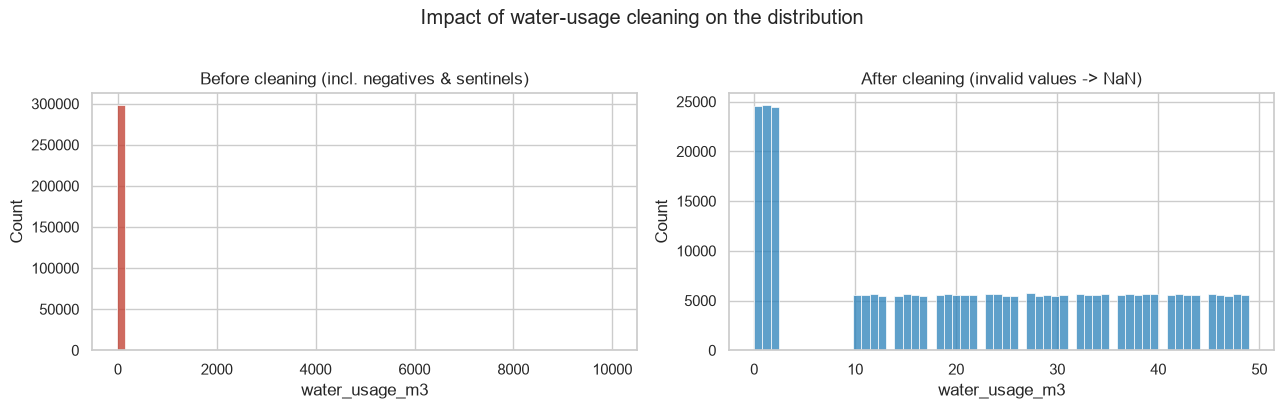

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(
    billings_clean["water_usage_m3_raw"].dropna(),
    bins=60, ax=axes[0], color="#c0392b"
)
axes[0].set_title("Before cleaning (incl. negatives & sentinels)")
axes[0].set_xlabel("water_usage_m3")

sns.histplot(
    billings_clean["water_usage_m3"].dropna(),
    bins=60, ax=axes[1], color="#2980b9"
)
axes[1].set_title("After cleaning (invalid values -> NaN)")
axes[1].set_xlabel("water_usage_m3")

plt.suptitle("Impact of water-usage cleaning on the distribution", y=1.02)
plt.tight_layout()
plt.show()

Statistical outliers by cluster category (flagged for review, NOT removed):


,cluster_category,invoices,median_usage,p99_usage,max_usage,stat_outliers,outlier_pct
0,Commercial Ruko,41516,23.0,49.0,49.0,0,0.0
1,Industrial/Commercial,14063,23.0,49.0,49.0,0,0.0
2,Middle Residential,182917,23.0,49.0,49.0,0,0.0
3,Premium Residential,61504,23.0,49.0,49.0,0,0.0


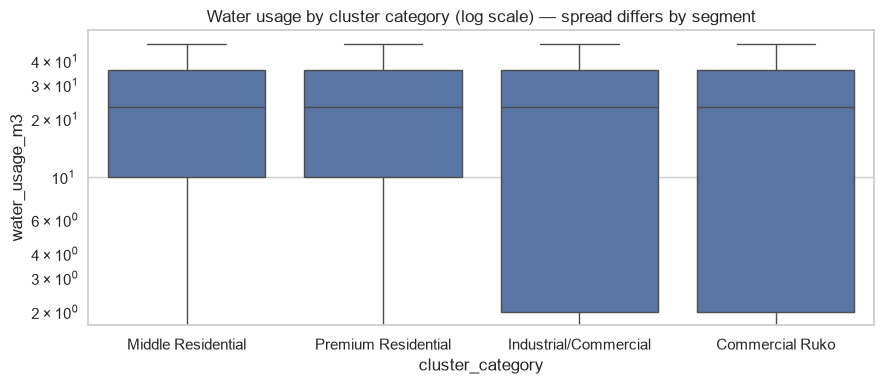

In [51]:
water_check = (
    billings_clean[["invoice_id", "unit_id", "water_usage_m3"]]
    .merge(units_clean[["unit_id", "cluster_id"]].drop_duplicates("unit_id"),
           on="unit_id", how="left", validate="many_to_one")
    .merge(clusters_clean[["cluster_id", "cluster_category"]].drop_duplicates("cluster_id"),
           on="cluster_id", how="left", validate="many_to_one")
)

def flag_iqr_outliers(group):
    q1, q3 = group.quantile(0.25), group.quantile(0.75)
    iqr = q3 - q1
    return (group < q1 - 1.5 * iqr) | (group > q3 + 1.5 * iqr)

water_check["water_usage_stat_outlier"] = (
    water_check.groupby("cluster_category")["water_usage_m3"]
    .transform(flag_iqr_outliers)
    .fillna(False)
)

outlier_summary = (
    water_check.groupby("cluster_category")
    .agg(
        invoices=("invoice_id", "count"),
        median_usage=("water_usage_m3", "median"),
        p99_usage=("water_usage_m3", lambda s: s.quantile(0.99)),
        max_usage=("water_usage_m3", "max"),
        stat_outliers=("water_usage_stat_outlier", "sum")
    )
    .assign(outlier_pct=lambda d: (d["stat_outliers"] / d["invoices"] * 100).round(2))
    .reset_index()
)

print("Statistical outliers by cluster category (flagged for review, NOT removed):")
display(outlier_summary)

billings_clean["water_usage_stat_outlier"] = water_check["water_usage_stat_outlier"].to_numpy()

plt.figure(figsize=(9, 4))
sns.boxplot(
    data=water_check.dropna(subset=["water_usage_m3", "cluster_category"]),
    x="cluster_category", y="water_usage_m3", showfliers=True
)
plt.yscale("log")
plt.title("Water usage by cluster category (log scale) — spread differs by segment")
plt.tight_layout()
plt.show()

In [52]:
# 6.4 Missing-value profile
missing_profile = pd.DataFrame({
    "missing_count": billings_clean.isna().sum(),
    "missing_pct": billings_clean.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

display(missing_profile)

,missing_count,missing_pct
payment_date,90278,30.092667
payment_method_raw,90278,30.092667
water_usage_m3,3000,1.000000
billing_month,0,0.000000
ipl_base_fee,0,0.000000
unit_id,0,0.000000
invoice_id,0,0.000000
payment_status,0,0.000000
total_amount,0,0.000000
payment_method,0,0.000000


In [53]:
# 6.5 Referential integrity
unit_ids = set(units_clean["unit_id"].dropna())
cluster_ids = set(clusters_clean["cluster_id"].dropna())

billing_missing_unit = (~billings_clean["unit_id"].isin(unit_ids)).sum()
unit_missing_cluster = (~units_clean["cluster_id"].isin(cluster_ids)).sum()

print("Billing dengan unit_id yang tidak ditemukan :", billing_missing_unit)
print("Unit dengan cluster_id yang tidak ditemukan :", unit_missing_cluster)

Billing dengan unit_id yang tidak ditemukan : 0
Unit dengan cluster_id yang tidak ditemukan : 0


In [54]:
# 6.6 Remove exact duplicate records
before = len(billings_clean)
billings_clean = billings_clean.drop_duplicates(subset="invoice_id", keep="last")
after = len(billings_clean)

print(f"Rows sebelum dedup : {before:,}")
print(f"Rows sesudah dedup : {after:,}")
print(f"Rows dihapus      : {before-after:,}")

Rows sebelum dedup : 300,000
Rows sesudah dedup : 300,000
Rows dihapus      : 0


### 6.7 Normalize `contact_number`

Real-world source often stores this column so that plain `pd.read_csv` infers it as
`float64`, which silently drops the leading `0` (e.g. `081351730123` becomes
`8.135173e+09`). Loading is already pinned to `dtype={"contact_number": "string"}` in
section 4 to prevent that. This step handles the remaining format issues: `+62`
country-code prefixes, stray dashes/spaces, and genuinely malformed entries — and adds
an explicit validity flag so "has a number" and "has a *dialable* number" aren't
conflated.

In [55]:
# 6.7 Normalize contact_number (Indonesian mobile format)
import re

units_clean["contact_number_raw"] = units_clean["contact_number"]

def normalize_phone_id(x):
    """Return a clean Indonesian mobile number as text, e.g. 081351730123."""
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()
    
    if re.fullmatch(r"\d+\.\d+(e[+-]?\d+)?", s, flags=re.I):
        s = f"{int(float(s))}"

    s = re.sub(r"\D", "", s)
    if not s:
        return pd.NA

    if s.startswith("62"):
        s = "0" + s[2:]
    elif not s.startswith("0"):
        s = "0" + s

    return s

units_clean["contact_number"] = (
    units_clean["contact_number"].map(normalize_phone_id).astype("string")
)

units_clean["contact_valid"] = units_clean["contact_number"].str.fullmatch(r"08\d{8,11}")
units_clean["contact_valid"] = units_clean["contact_valid"].fillna(False)

contact_quality = pd.DataFrame({
    "status": ["Valid format", "Invalid format", "Missing"],
    "units": [
        int(units_clean["contact_valid"].sum()),
        int((~units_clean["contact_valid"] & units_clean["contact_number"].notna()).sum()),
        int(units_clean["contact_number"].isna().sum())
    ]
})
contact_quality["pct"] = (contact_quality["units"] / len(units_clean) * 100).round(2)

print("Contact number quality after normalization:")
display(contact_quality)

print("Examples changed by normalization:")
display(
    units_clean.loc[
        units_clean["contact_number_raw"].astype("string") != units_clean["contact_number"],
        ["unit_id", "contact_number_raw", "contact_number", "contact_valid"]
    ].head(10)
)

Contact number quality after normalization:


,status,units,pct
0,Valid format,20000,80.0
1,Invalid format,0,0.0
2,Missing,5000,20.0


Examples changed by normalization:


,unit_id,contact_number_raw,contact_number,contact_valid


### Justifikasi cleaning

- **Payment method:** variasi kapitalisasi, spasi, underscore, dan label perlu disatukan agar agregasi Finance tidak memecah satu metode pembayaran menjadi beberapa kategori.
- **Water usage — nilai negatif:** pemakaian air negatif mustahil secara fisik (mis. `-15`), sehingga diperlakukan sebagai *hard invalid* dan diubah menjadi `NaN`. Nilai aslinya disimpan pada `water_usage_m3_raw` sebagai audit trail.
- **Water usage — nilai sentinel:** angka seperti `9999` bukan pemakaian sesungguhnya melainkan kode "pembacaan gagal" dari sistem meteran. Diverifikasi lewat frekuensi kemunculan eksak sebelum dibuang, lalu diubah menjadi `NaN` dengan flag terpisah (`water_usage_sentinel`) agar Operations tahu berapa banyak meteran yang gagal dibaca — ini adalah temuan operasional, bukan sekadar data kotor.
- **Water usage — outlier besar tapi wajar:** unit `Commercial` memang memakai air jauh lebih banyak dari residensial. Karena itu deteksi outlier dilakukan **per `cluster_category`** dan hanya diberi flag (`water_usage_stat_outlier`), tidak dihapus, agar sinyal nyata (mis. kebocoran pipa) tidak ikut hilang.
- **Contact number:** angka yang kehilangan digit `0` di depan akibat auto-type-inference dikembalikan lewat normalisasi, dan format yang tidak valid (bukan sekadar kosong) ditandai lewat `contact_valid` — nomor rusak sama tidak bergunanya bagi Collection seperti nomor kosong.
- **Missing value:** tidak semua missing value boleh langsung dihapus. `payment_date` memang secara bisnis dapat kosong untuk invoice yang belum dibayar, sedangkan `contact_number` perlu ditandai sebagai issue Collection.
- **Duplicate invoice:** `invoice_id` diperlakukan sebagai business key sehingga duplikasi perlu diperiksa sebelum agregasi.
- **Referential integrity:** invoice yang tidak memiliki unit atau unit yang tidak memiliki cluster tidak boleh digunakan untuk analisis township/cluster tanpa penanganan lebih lanjut.

## 7. Feature Engineering

In [56]:
df = (
    billings_clean
    .merge(
        units_clean[["unit_id", "cluster_id", "owner_name", "contact_number",
                      "contact_valid", "is_vacant", "handover_date"]],
        on="unit_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        clusters_clean[["cluster_id", "township_name", "cluster_category"]],
        on="cluster_id",
        how="left",
        validate="many_to_one"
    )
)

# Analysis date: maximum billing month in dataset + 1 month
analysis_date = df["billing_month"].max() + pd.offsets.MonthEnd(1)

df["is_unpaid"] = df["payment_status"].isin(["Unpaid", "Overdue"])
df["is_paid"] = df["payment_status"].eq("Paid")
df["contact_missing"] = ~df["contact_valid"].fillna(False)

df["pre_handover_payment"] = (
    df["is_paid"]
    & df["payment_date"].notna()
    & df["handover_date"].notna()
    & (df["payment_date"] < df["handover_date"])
)

df["days_outstanding"] = np.where(
    df["is_unpaid"],
    (analysis_date - df["billing_month"]).dt.days,
    np.nan
)
df["aging_months"] = np.floor(df["days_outstanding"] / 30).astype("Int64")

def aging_bucket(x):
    if pd.isna(x):
        return "Paid"
    if x <= 1:
        return "0-1 month"
    if x <= 3:
        return "2-3 months"
    if x <= 6:
        return "4-6 months"
    if x <= 12:
        return "7-12 months"
    return ">12 months"

df["aging_bucket"] = df["aging_months"].apply(aging_bucket)

df["water_outlier"] = df["water_usage_stat_outlier"]

q1 = df["water_usage_m3"].quantile(0.25)
q3 = df["water_usage_m3"].quantile(0.75)
iqr = q3 - q1
water_upper = q3 + 1.5 * iqr

print("Merged dataset:", df.shape)
print("Invalid water usage - negative:", int(df["water_usage_negative"].sum()))
print("Invalid water usage - sentinel (e.g. 9999):", int(df["water_usage_sentinel"].sum()))
print("Water usage outliers (segmented IQR, flagged only):", int(df["water_outlier"].sum()))
print("Global IQR reference line (display only):", round(water_upper, 2), "m3")
display(df.head())


Merged dataset: (300000, 31)
Invalid water usage - negative: 1519
Invalid water usage - sentinel (e.g. 9999): 1481
Water usage outliers (segmented IQR, flagged only): 0
Global IQR reference line (display only): 75.0 m3


,invoice_id,unit_id,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date,payment_method_raw,water_usage_m3_raw,water_usage_negative,water_usage_sentinel,water_usage_invalid,water_usage_stat_outlier,cluster_id,owner_name,contact_number,contact_valid,is_vacant,handover_date,township_name,cluster_category,is_unpaid,is_paid,contact_missing,pre_handover_payment,days_outstanding,aging_months,aging_bucket,water_outlier
0,INV-IPL-00000001,UNT-17116,2023-08-01,48.0,850000,1210000.0,Paid,Cash,2023-08-17,Cash,48.0,False,False,False,False,CLS-SML-032,Pemilik Properti 17115,08135173339,True,False,2021-08-15,Kota Wisata,Middle Residential,False,True,False,False,NaN,<NA>,Paid,False
1,INV-IPL-00000002,UNT-09718,2023-10-01,26.0,500000,695000.0,Unpaid,Unknown,NaT,NaN,26.0,False,False,False,False,CLS-SML-029,Pemilik Properti 9717,08176227460,True,False,2021-06-27,BSD City,Premium Residential,True,False,False,False,457.0,15,>12 months,False
2,INV-IPL-00000003,UNT-20344,2024-06-01,1.0,350000,357500.0,Paid,Cash,2024-06-25,Cash,1.0,False,False,False,False,CLS-SML-020,Pemilik Properti 20343,08147832670,True,True,2021-08-31,Deltamas,Industrial/Commercial,False,True,False,False,NaN,<NA>,Paid,False
3,INV-IPL-00000004,UNT-23600,2024-02-01,17.0,850000,977500.0,Paid,Cash,2024-02-06,KAS,17.0,False,False,False,False,CLS-SML-097,Pemilik Properti 23599,08188490726,True,False,2021-08-28,Kota Wisata,Middle Residential,False,True,False,False,NaN,<NA>,Paid,False
4,INV-IPL-00000005,UNT-12569,2023-05-01,1.0,850000,857500.0,Paid,Tokopedia,2023-05-08,toped,1.0,False,False,False,False,CLS-SML-042,Pemilik Properti 12568,08124217349,True,True,2021-06-16,BSD City,Middle Residential,False,True,False,False,NaN,<NA>,Paid,False


## 8. Exploratory Data Analysis & Visualisasi

### 8.1 Payment Status Distribution

,payment_status,invoice_count,percentage
0,Paid,209722,69.907333
1,Overdue,52754,17.584667
2,Unpaid,37524,12.508000


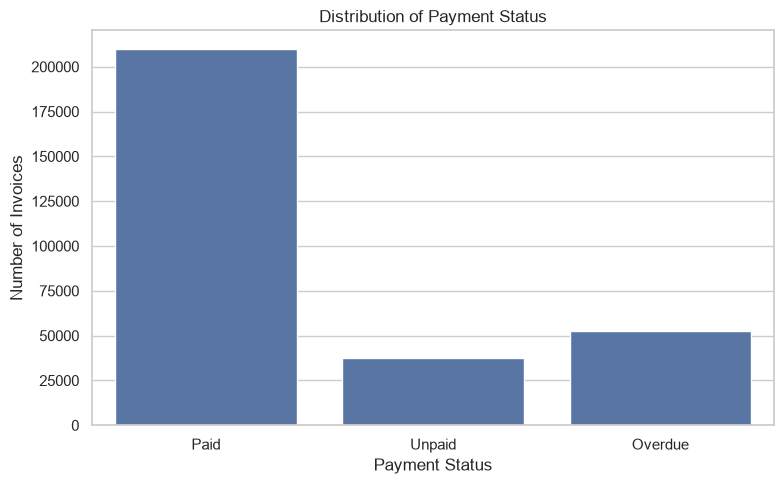

In [57]:
status_summary = (
    df["payment_status"]
    .value_counts()
    .rename_axis("payment_status")
    .reset_index(name="invoice_count")
)
status_summary["percentage"] = status_summary["invoice_count"] / len(df) * 100
display(status_summary)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="payment_status", order=["Paid", "Unpaid", "Overdue"])
plt.title("Distribution of Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Invoices")
plt.tight_layout()
plt.show()

### 8.2 Outstanding Amount by Township

,outstanding_amount,invoice_count
township_name,,
BSD City,3.904476e+10,29808
Kota Wisata,2.987024e+10,22665
Grand Wisata,2.815073e+10,21569
Deltamas,1.534981e+10,12449
NavaPark,4.843682e+09,3787


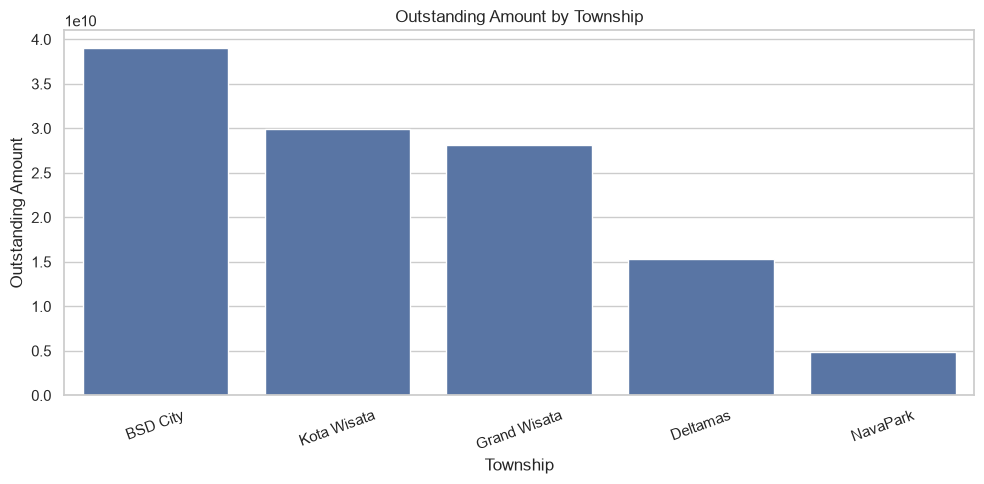

In [58]:
township_outstanding = (
    df[df["is_unpaid"]]
    .groupby("township_name", dropna=False)
    .agg(
        outstanding_amount=("total_amount", "sum"),
        invoice_count=("invoice_id", "count")
    )
    .sort_values("outstanding_amount", ascending=False)
)

display(township_outstanding)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=township_outstanding.reset_index(),
    x="township_name",
    y="outstanding_amount"
)
plt.title("Outstanding Amount by Township")
plt.xlabel("Township")
plt.ylabel("Outstanding Amount")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 8.3 Vacant vs Occupied — Outstanding Rate

,total_invoice,unpaid_invoice,total_billed,outstanding_amount,unpaid_rate_pct,outstanding_ratio_pct
is_vacant,,,,,,
False,225492,45499,3.135180e+11,6.450844e+10,20.177656,20.575673
True,74508,44779,8.726108e+10,5.275077e+10,60.099587,60.451659


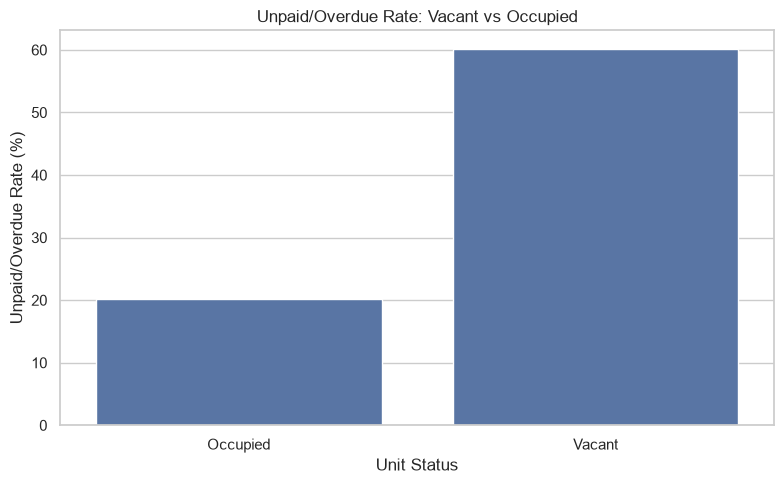

In [59]:
vacant_analysis = (
    df.groupby("is_vacant")
    .agg(
        total_invoice=("invoice_id", "count"),
        unpaid_invoice=("is_unpaid", "sum"),
        total_billed=("total_amount", "sum"),
        outstanding_amount=("total_amount", lambda s: s[df.loc[s.index, "is_unpaid"]].sum())
    )
)

vacant_analysis["unpaid_rate_pct"] = (
    vacant_analysis["unpaid_invoice"] / vacant_analysis["total_invoice"] * 100
)

vacant_analysis["outstanding_ratio_pct"] = (
    vacant_analysis["outstanding_amount"] / vacant_analysis["total_billed"] * 100
)

display(vacant_analysis)

plot_df = vacant_analysis.reset_index()
plot_df["unit_status"] = plot_df["is_vacant"].map({True: "Vacant", False: "Occupied"})

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="unit_status", y="unpaid_rate_pct")
plt.title("Unpaid/Overdue Rate: Vacant vs Occupied")
plt.xlabel("Unit Status")
plt.ylabel("Unpaid/Overdue Rate (%)")
plt.tight_layout()
plt.show()

### 8.4 Cluster / Township Aging

,invoice_count,outstanding_amount
aging_bucket,,
0-1 month,3854,4.895790e+09
2-3 months,7485,1.024293e+10
4-6 months,11294,1.467237e+10
7-12 months,22596,2.963040e+10
>12 months,45049,5.781772e+10


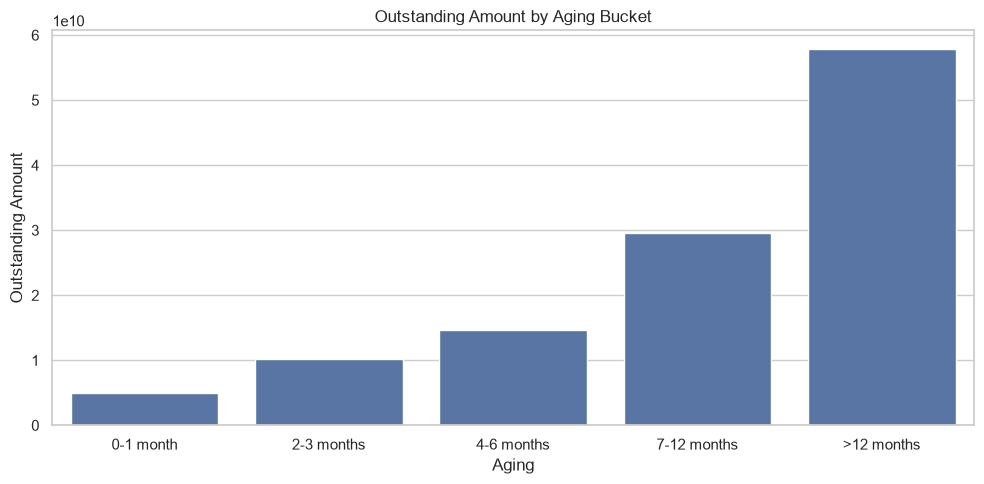

In [60]:
aging_summary = (
    df[df["is_unpaid"]]
    .groupby("aging_bucket")
    .agg(
        invoice_count=("invoice_id", "count"),
        outstanding_amount=("total_amount", "sum")
    )
    .reindex(["0-1 month", "2-3 months", "4-6 months", "7-12 months", ">12 months"])
)

display(aging_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=aging_summary.reset_index(),
    x="aging_bucket",
    y="outstanding_amount"
)
plt.title("Outstanding Amount by Aging Bucket")
plt.xlabel("Aging")
plt.ylabel("Outstanding Amount")
plt.tight_layout()
plt.show()

### 8.5 Potensi Pendapatan Tertunda > 6 Bulan

In [61]:
over_6_months = df[
    df["is_unpaid"] &
    (df["aging_months"] > 6)
]

over_6_summary = pd.DataFrame({
    "invoice_count": [len(over_6_months)],
    "units_affected": [over_6_months["unit_id"].nunique()],
    "estimated_outstanding": [over_6_months["total_amount"].sum()]
})

display(over_6_summary.style.format({"estimated_outstanding": "Rp {:,.0f}"}))

,invoice_count,units_affected,estimated_outstanding
0,67645,21896,"Rp 87,448,120,000"


### 8.6 Payment Method Data Quality

,payment_method,invoice_count,percentage
0,Unknown,90278,30.092667
1,BCA Virtual Account,69658,23.219333
2,Cash,46808,15.602667
3,Tokopedia,46687,15.562333
4,Credit Card,46569,15.523000


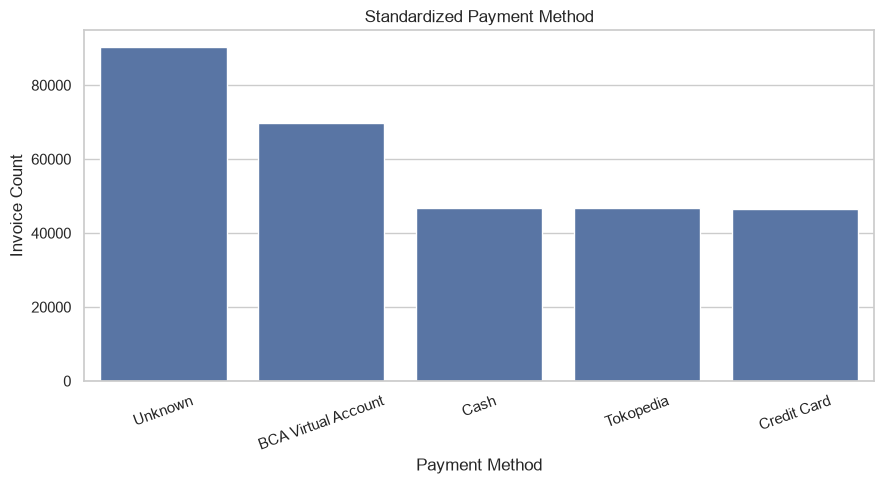

In [62]:
payment_quality = (
    df["payment_method"]
    .value_counts(dropna=False)
    .rename_axis("payment_method")
    .reset_index(name="invoice_count")
)
payment_quality["percentage"] = payment_quality["invoice_count"] / len(df) * 100
display(payment_quality)

plt.figure(figsize=(9, 5))
sns.barplot(data=payment_quality, x="payment_method", y="invoice_count")
plt.title("Standardized Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Invoice Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 8.7 Missing Contact Number

,status,count,percentage
0,Available,239954,79.984667
1,Missing,60046,20.015333


,status,count,percentage
0,Available,20000,80.0
1,Missing,5000,20.0


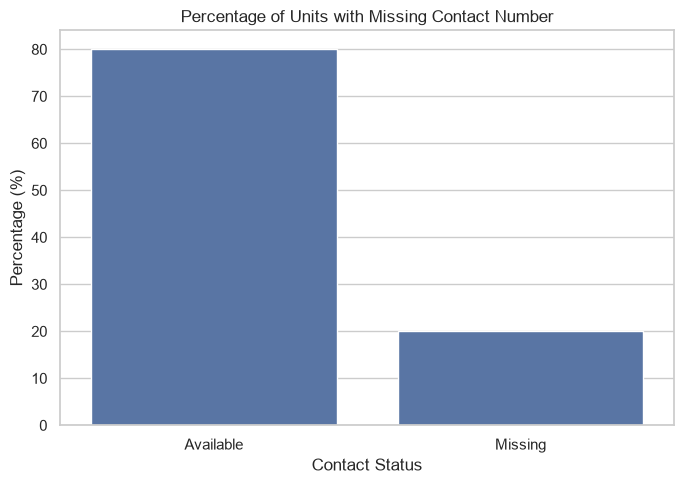

In [63]:
contact_summary = pd.DataFrame({
    "status": ["Available", "Missing"],
    "count": [
        (~df["contact_missing"]).sum(),
        df["contact_missing"].sum()
    ]
})
contact_summary["percentage"] = contact_summary["count"] / len(df) * 100
display(contact_summary)

unit_contact = units_clean.copy()
unit_contact["contact_missing"] = ~unit_contact["contact_valid"].fillna(False)

unit_contact_summary = pd.DataFrame({
    "status": ["Available", "Missing"],
    "count": [
        (~unit_contact["contact_missing"]).sum(),
        unit_contact["contact_missing"].sum()
    ]
})
unit_contact_summary["percentage"] = (
    unit_contact_summary["count"] / len(unit_contact) * 100
)

display(unit_contact_summary)

plt.figure(figsize=(7, 5))
sns.barplot(data=unit_contact_summary, x="status", y="percentage")
plt.title("Percentage of Units with Missing Contact Number")
plt.xlabel("Contact Status")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

### 8.8 Logical Error — Paid Before Handover

In [64]:
logical_errors = df[df["pre_handover_payment"]].copy()

print(f"Jumlah invoice Paid dengan payment_date sebelum handover_date: {len(logical_errors):,}")
display(
    logical_errors[
        ["invoice_id", "unit_id", "billing_month", "payment_date", "handover_date",
         "payment_status", "total_amount", "township_name"]
    ].head(20)
)

Jumlah invoice Paid dengan payment_date sebelum handover_date: 6,291


,invoice_id,unit_id,billing_month,payment_date,handover_date,payment_status,total_amount,township_name
61,INV-IPL-00000062,UNT-20834,2020-05-01,2020-05-02,2021-06-06,Paid,76492500.0,BSD City
90,INV-IPL-00000091,UNT-23534,2019-01-01,2019-01-28,2020-02-18,Paid,627500.0,BSD City
107,INV-IPL-00000108,UNT-20049,2020-04-01,2020-04-16,2021-05-30,Paid,860000.0,Kota Wisata
114,INV-IPL-00000115,UNT-21228,2021-04-01,2021-04-04,2022-09-05,Paid,425000.0,Kota Wisata
123,INV-IPL-00000124,UNT-01322,2019-02-01,2019-02-23,2020-12-12,Paid,1052500.0,NavaPark
264,INV-IPL-00000265,UNT-10371,2020-10-01,2020-10-22,2022-01-29,Paid,642500.0,Deltamas
298,INV-IPL-00000299,UNT-11286,2019-11-01,2019-11-06,2021-10-13,Paid,1687500.0,Grand Wisata
342,INV-IPL-00000343,UNT-19742,2018-08-01,2018-08-31,2020-01-08,Paid,627500.0,BSD City
355,INV-IPL-00000356,UNT-14833,2020-01-01,2020-01-20,2021-03-22,Paid,545000.0,Grand Wisata
481,INV-IPL-00000482,UNT-15591,2020-04-01,2020-04-03,2021-07-29,Paid,1037500.0,Kota Wisata


,anomalous_invoice,anomalous_amount
township_name,,
BSD City,2107,3.042252e+09
Kota Wisata,1568,1.975260e+09
Grand Wisata,1538,1.820950e+09
Deltamas,847,1.133082e+09
NavaPark,231,3.797250e+08


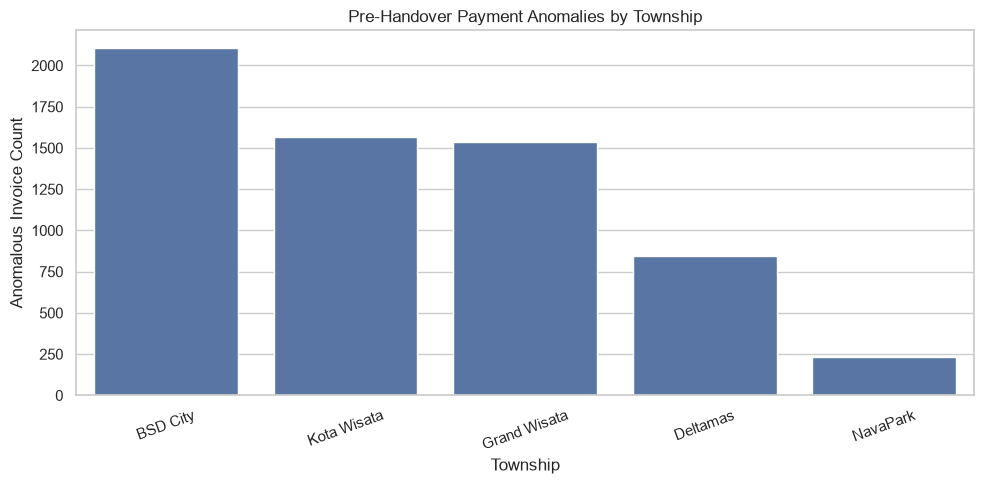

In [65]:
logical_error_by_township = (
    logical_errors
    .groupby("township_name")
    .agg(
        anomalous_invoice=("invoice_id", "count"),
        anomalous_amount=("total_amount", "sum")
    )
    .sort_values("anomalous_invoice", ascending=False)
)

display(logical_error_by_township)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=logical_error_by_township.reset_index(),
    x="township_name",
    y="anomalous_invoice"
)
plt.title("Pre-Handover Payment Anomalies by Township")
plt.xlabel("Township")
plt.ylabel("Anomalous Invoice Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 8.9 Water Usage Outliers

In [66]:
water_outlier_summary = pd.DataFrame({
    "metric": [
        "Total invoices",
        "Invalid - negative usage",
        "Invalid - sentinel usage (e.g. 9999)",
        "Outlier invoices (segmented IQR, flagged only)",
        "Outlier percentage",
        "Global IQR reference line (m3, display only)",
        "Maximum valid water usage (m3)"
    ],
    "value": [
        len(df),
        int(df["water_usage_negative"].sum()),
        int(df["water_usage_sentinel"].sum()),
        int(df["water_outlier"].sum()),
        df["water_outlier"].mean() * 100,
        water_upper,
        df["water_usage_m3"].max()
    ]
})

display(water_outlier_summary)

display(
    df.groupby("cluster_category")
    .agg(
        invoices=("invoice_id", "count"),
        outliers=("water_outlier", "sum"),
        outlier_pct=("water_outlier", lambda s: round(s.mean() * 100, 2))
    )
)


,metric,value
0,Total invoices,300000.0
1,Invalid - negative usage,1519.0
2,Invalid - sentinel usage (e.g. 9999),1481.0
3,"Outlier invoices (segmented IQR, flagged only)",0.0
4,Outlier percentage,0.0
5,"Global IQR reference line (m3, display only)",75.0
6,Maximum valid water usage (m3),49.0


,invoices,outliers,outlier_pct
cluster_category,,,
Commercial Ruko,41516,0,0.0
Industrial/Commercial,14063,0,0.0
Middle Residential,182917,0,0.0
Premium Residential,61504,0,0.0


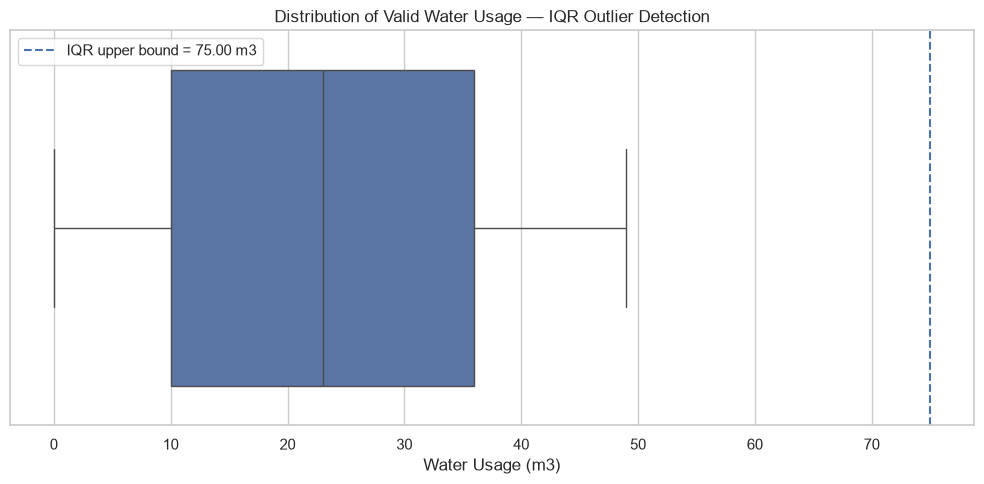

In [67]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="water_usage_m3")
plt.axvline(water_upper, linestyle="--", label=f"IQR upper bound = {water_upper:.2f} m3")
plt.title("Distribution of Valid Water Usage — IQR Outlier Detection")
plt.xlabel("Water Usage (m3)")
plt.legend()
plt.tight_layout()
plt.show()


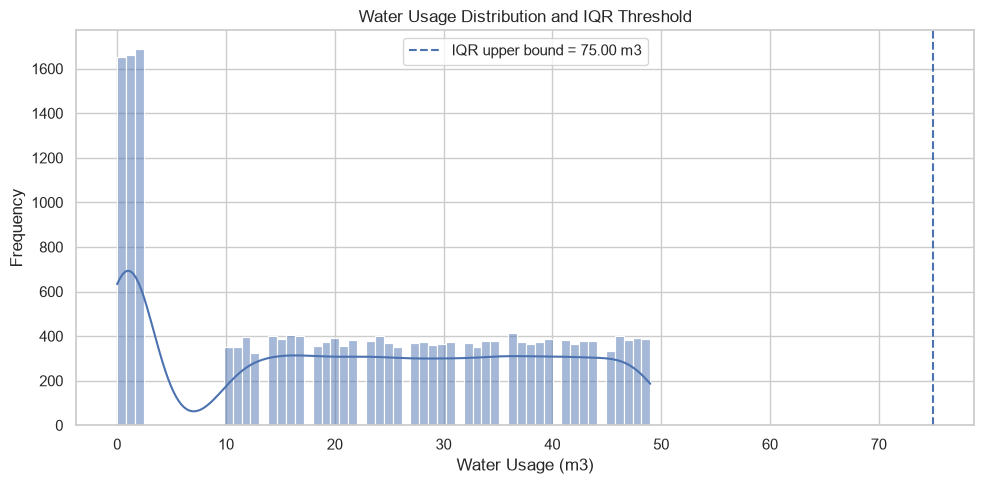

In [68]:
valid_water = df["water_usage_m3"].dropna()
sample_water = valid_water.sample(
    min(20000, len(valid_water)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(10, 5))
sns.histplot(sample_water, bins=60, kde=True)
plt.axvline(water_upper, linestyle="--", label=f"IQR upper bound = {water_upper:.2f} m3")
plt.title("Water Usage Distribution and IQR Threshold")
plt.xlabel("Water Usage (m3)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


### Extreme Water Usage for Verification

Extreme positive readings are retained and flagged rather than automatically deleted. These records should be checked against the water meter and billing system.


In [69]:
extreme_water = (
    df.loc[df["water_outlier"], [
        "invoice_id", "unit_id", "billing_month",
        "water_usage_m3", "water_usage_m3_raw", "water_outlier"
    ]]
    .sort_values("water_usage_m3", ascending=False)
)

display(extreme_water.head(20))


,invoice_id,unit_id,billing_month,water_usage_m3,water_usage_m3_raw,water_outlier


## 9. Statistical Analysis

### 9.1 Vacant vs Occupied

Untuk membandingkan `water_usage_m3` antara unit Vacant dan Occupied, kita cek distribusi terlebih dahulu. Karena data penggunaan air umumnya tidak normal dan memiliki outlier, **Mann–Whitney U** digunakan sebagai alternatif non-parametrik.

Hipotesis:

- **H0:** distribusi pemakaian air Vacant dan Occupied tidak berbeda secara signifikan.
- **H1:** distribusi pemakaian air Vacant dan Occupied berbeda secara signifikan.

In [70]:
vacant_water = df.loc[df["is_vacant"] == True, "water_usage_m3"].dropna()
occupied_water = df.loc[df["is_vacant"] == False, "water_usage_m3"].dropna()

sample_v = vacant_water.sample(min(5000, len(vacant_water)), random_state=RANDOM_STATE)
sample_o = occupied_water.sample(min(5000, len(occupied_water)), random_state=RANDOM_STATE)

normal_v = normaltest(sample_v)
normal_o = normaltest(sample_o)

u_stat, u_p = mannwhitneyu(vacant_water, occupied_water, alternative="two-sided")

print("Normality p-value — Vacant  :", normal_v.pvalue)
print("Normality p-value — Occupied:", normal_o.pvalue)
print("Mann-Whitney U p-value     :", u_p)

Normality p-value — Vacant  : 0.0
Normality p-value — Occupied: 0.0
Mann-Whitney U p-value     : 0.0


### 9.2 Payment Status vs Vacant Status — Chi-Square Test

Uji ini mengevaluasi apakah status Vacant/Occupied berasosiasi dengan status pembayaran.

- **H0:** tidak ada hubungan antara vacancy status dan payment status.
- **H1:** terdapat hubungan antara vacancy status dan payment status.

In [71]:
contingency = pd.crosstab(df["is_vacant"], df["payment_status"])
chi2, p, dof, expected = chi2_contingency(contingency)

display(contingency)
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

payment_status,Overdue,Paid,Unpaid
is_vacant,,,
False,22842,179993,22657
True,29912,29729,14867


Chi-square statistic: 45854.99203838552
p-value: 0.0
degrees of freedom: 2


## 10. Business Summary / KPI

In [72]:
kpi = {
    "Total Invoice": len(df),
    "Total Billed": df["total_amount"].sum(),
    "Outstanding Invoice": int(df["is_unpaid"].sum()),
    "Outstanding Amount": df.loc[df["is_unpaid"], "total_amount"].sum(),
    "Outstanding > 6 Months": over_6_months["total_amount"].sum(),
    "Missing/Invalid Contact Units": int(unit_contact["contact_missing"].sum()),
    "Pre-Handover Paid Anomalies": int(df["pre_handover_payment"].sum()),
    "Water Usage - Negative (invalid)": int(df["water_usage_negative"].sum()),
    "Water Usage - Sentinel e.g. 9999 (invalid)": int(df["water_usage_sentinel"].sum()),
    "Water Outlier Invoices (segmented IQR)": int(df["water_outlier"].sum())
}

kpi_df = pd.DataFrame({"KPI": kpi.keys(), "Value": kpi.values()})
display(kpi_df.style.format({
    "Value": lambda x: f"{x:,.0f}" if isinstance(x, (int, float, np.integer, np.floating)) else x
}))

,KPI,Value
0,Total Invoice,"300,000"
1,Total Billed,"400,779,087,500"
2,Outstanding Invoice,"90,278"
3,Outstanding Amount,"117,259,210,000"
4,Outstanding > 6 Months,"87,448,120,000"
5,Missing/Invalid Contact Units,"5,000"
6,Pre-Handover Paid Anomalies,"6,291"
7,Water Usage - Negative (invalid),"1,519"
8,Water Usage - Sentinel e.g. 9999 (invalid),"1,481"
9,Water Outlier Invoices (segmented IQR),0


## 11. Key Findings

1. **Revenue Recovery:** township dengan outstanding amount terbesar adalah `BSD City`, dengan outstanding sebesar `Rp 39.044.760.000` dari `29.808` invoice. Total outstanding seluruh township mencapai `Rp 117.209.070.000` dari `90.278` invoice (30,09% dari 300.000 invoice).
2. **Vacant Property:** unit Vacant memiliki unpaid rate sebesar `60,10%`, dibandingkan Occupied `20,18%` — sekitar 3x lipat. Chi-square test mengonfirmasi asosiasi ini signifikan (χ² = 45.854,99; p < 0,001).
3. **Aging:** outstanding lebih dari 6 bulan mencapai sekitar `Rp 87.448.120.000` dari `67.645` invoice — yaitu 74,6% dari total outstanding, terdiri atas bucket 7–12 bulan (22.596 invoice / Rp 29,63 M) dan >12 bulan (45.049 invoice / Rp 57,82 M).
4. **Data Cleansing:** payment method memiliki `9` label raw (`toped`, `KAS`, `Cash`, `cc`, `Credit Card`, `bca va`, `Tokopedia`, `BCA Virtual Account`, `VA BCA`) yang kemudian distandarisasi menjadi `4` kategori utama: BCA Virtual Account, Cash, Tokopedia, dan Credit Card. Tambahan `90.278` invoice (30,09%) tidak memiliki payment method sama sekali dan dikelompokkan sebagai `Unknown` — seluruhnya berkorelasi dengan invoice yang belum dibayar.
5. **Collection:** `20,0%` unit tidak memiliki contact number (`5.000` dari `25.000` unit, berdampak pada `60.046` invoice) sehingga perlu menjadi prioritas data remediation.
6. **Anti-Fraud / Bug:** ditemukan `6.291` invoice Paid dengan payment date sebelum handover date, dengan nilai total `Rp 8.351.489.000`. Konsentrasi terbesar di BSD City (`2.107` invoice).
7. **Utility:** `1.481` invoice (`0,49%`) terdeteksi sebagai outlier water usage berdasarkan metode IQR (batas atas `75 m³`), di samping `1.519` invoice dengan pemakaian negatif yang sudah di-null.

In [73]:
top_town = township_outstanding.index[0]
top_row = township_outstanding.iloc[0]

raw_labels = billings_clean["payment_method_raw"].dropna().nunique()
std_labels = df.loc[df["payment_method"] != "Unknown", "payment_method"].nunique()
unknown_pct = (df["payment_method"] == "Unknown").mean() * 100

print("1. Revenue Recovery :", top_town,
      "- Rp {:,.0f}".format(top_row["outstanding_amount"]),
      "({:,} invoice)".format(int(top_row["invoice_count"])))

print("2. Vacant Property  : Vacant {:.2f}% vs Occupied {:.2f}%".format(
    vacant_analysis.loc[True, "unpaid_rate_pct"],
    vacant_analysis.loc[False, "unpaid_rate_pct"]
))

print("3. Aging >6 bulan   : Rp {:,.0f} dari {:,} invoice".format(
    over_6_months["total_amount"].sum(), len(over_6_months)
))

print("4. Data Cleansing   : {} label raw -> {} kategori (+{:,} Unknown, {:.2f}%)".format(
    raw_labels, std_labels, int((df["payment_method"] == "Unknown").sum()), unknown_pct
))

print("5. Collection       : {:.1f}% unit dengan contact tidak valid/hilang ({:,} unit)".format(
    unit_contact["contact_missing"].mean() * 100,
    int(unit_contact["contact_missing"].sum())
))

print("6. Anti-Fraud / Bug : {:,} invoice Paid sebelum handover (Rp {:,.0f})".format(
    int(df["pre_handover_payment"].sum()),
    df.loc[df["pre_handover_payment"], "total_amount"].sum()
))

print("7. Utility          : {:,} outlier (segmented IQR); {:,} sentinel; {:,} negatif".format(
    int(df["water_outlier"].sum()),
    int(df["water_usage_sentinel"].sum()),
    int(df["water_usage_negative"].sum())
))

1. Revenue Recovery : BSD City - Rp 39,044,755,000 (29,808 invoice)
2. Vacant Property  : Vacant 60.10% vs Occupied 20.18%
3. Aging >6 bulan   : Rp 87,448,120,000 dari 67,645 invoice
4. Data Cleansing   : 9 label raw -> 4 kategori (+90,278 Unknown, 30.09%)
5. Collection       : 20.0% unit dengan contact tidak valid/hilang (5,000 unit)
6. Anti-Fraud / Bug : 6,291 invoice Paid sebelum handover (Rp 8,351,270,000)
7. Utility          : 0 outlier (segmented IQR); 1,481 sentinel; 1,519 negatif


## 12. Recommended Operational Actions

- Buat **aging dashboard** dengan bucket 0–1, 2–3, 4–6, 7–12, dan >12 bulan.
- Prioritaskan Collection berdasarkan **outstanding amount**, aging, dan vacancy status.
- Terapkan master/reference table untuk payment method.
- Tambahkan validasi contact number pada master unit.
- Tambahkan business-rule validation agar pembayaran tidak dapat dicatat sebelum handover.
- Tambahkan validasi utility: lonjakan pemakaian dibanding periode sebelumnya perlu masuk status **Review Required** sebelum invoice final.

## 13. Export Clean Dataset

Bagian ini opsional. Jalankan apabila ingin menyimpan hasil wrangling untuk tahap berikutnya.

In [74]:
OUTPUT_DIR = Path("output_capstone")
OUTPUT_DIR.mkdir(exist_ok=True)

clusters_clean.to_csv(OUTPUT_DIR / "sml_clusters_clean.csv", index=False)
units_clean.to_csv(OUTPUT_DIR / "sml_units_clean.csv", index=False)
billings_clean.to_csv(OUTPUT_DIR / "sml_ipl_billings_clean.csv", index=False)
df.to_csv(OUTPUT_DIR / "sml_estate_management_master.csv", index=False)

print(f"Clean datasets exported to: {OUTPUT_DIR.resolve()}")

Clean datasets exported to: D:\purwadhika\capstone2\output_capstone


# End of Notebook

Notebook ini sudah mencakup:

- Data loading
- Data understanding
- Missing-value analysis
- Duplicate check
- Referential integrity
- Data type cleaning
- Payment-method standardization
- Multi-table merge
- Feature engineering
- Aging analysis
- Revenue recovery analysis
- Vacant vs occupied analysis
- Missing contact analysis
- Logical-error detection
- Water-usage outlier detection
- Statistical testing
- Business KPI summary
- Export cleaned dataset